In [23]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, precision_recall_curve

In [4]:
sns.set_theme(style = "whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [11]:
df = pd.read_csv("Bank_Churn_Classification_Dataset.csv")

df.head()

,Unnamed: 0,CustomerID,Gender,SeniorCitizen,Tenure,MonthlyCharges,Contract,PaymentMethod,Churn,TotalCharges
0,0,0,Male,0,55,111.88,Two year,Mailed check,0,6153.40
1,1,1,Female,1,36,58.70,Two year,Electronic check,0,2113.20
2,2,2,Male,0,37,118.86,One year,Electronic check,0,4397.82
3,3,3,Male,1,14,96.14,Month-to-month,Mailed check,1,1345.96
4,4,4,Male,1,27,28.05,Two year,Mailed check,0,757.35


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      10000 non-null  int64  
 1   CustomerID      10000 non-null  int64  
 2   Gender          10000 non-null  object 
 3   SeniorCitizen   10000 non-null  int64  
 4   Tenure          10000 non-null  int64  
 5   MonthlyCharges  10000 non-null  float64
 6   Contract        10000 non-null  object 
 7   PaymentMethod   10000 non-null  object 
 8   Churn           10000 non-null  int64  
 9   TotalCharges    10000 non-null  float64
dtypes: float64(2), int64(5), object(3)
memory usage: 781.4+ KB
Data Info: None
Dataset Shape: (10000, 10)
Descriptive Statistics:          Unnamed: 0   CustomerID Gender  SeniorCitizen        Tenure  \
count   10000.00000  10000.00000  10000   10000.000000  10000.000000   
unique          NaN          NaN      2            NaN           NaN   
top  

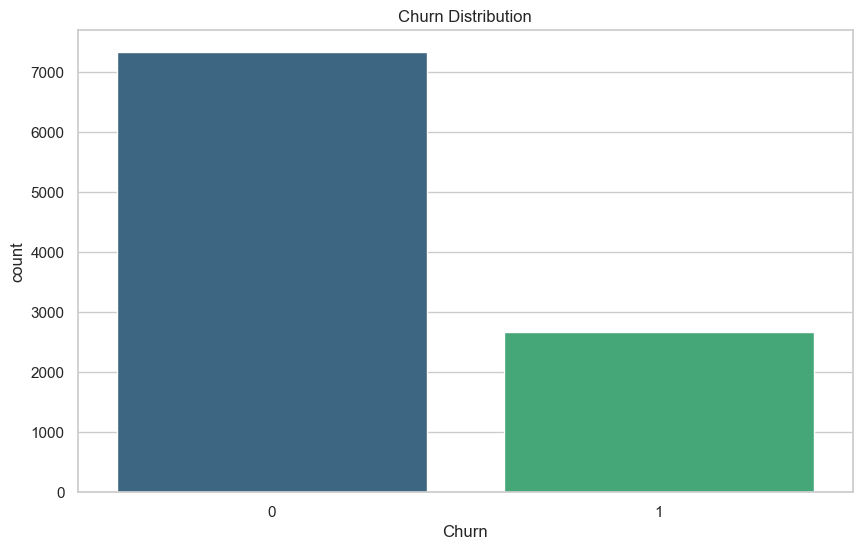

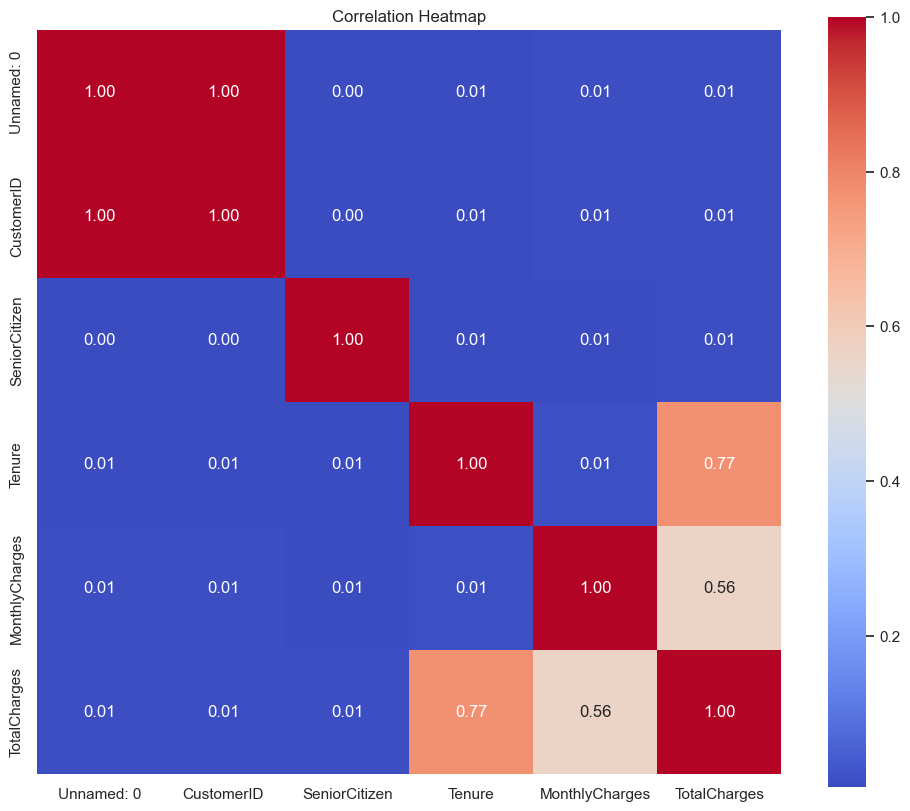

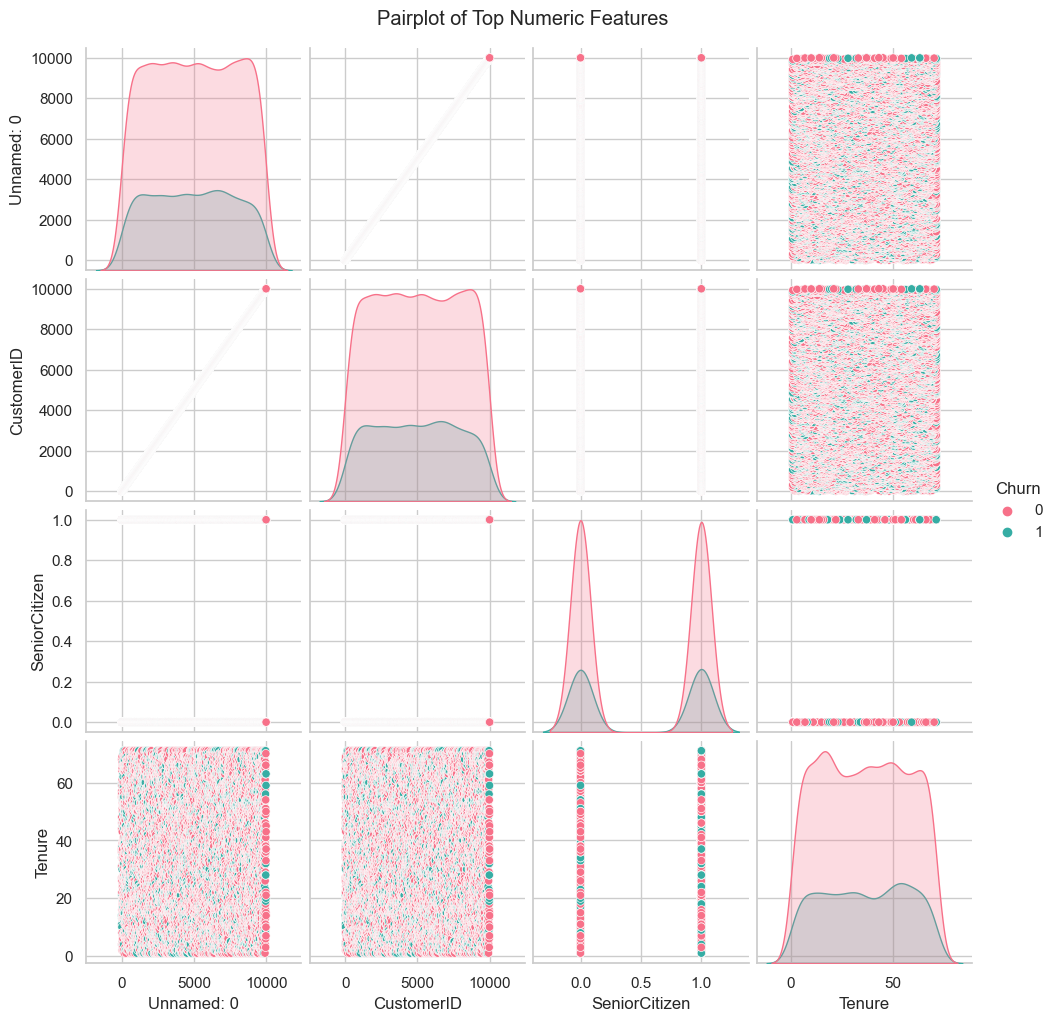

In [12]:
def perform_eda(df, target_col):
    print(f"Data Info: {df.info()}")

    print(f"Dataset Shape: {df.shape}")

    print(f"Descriptive Statistics: {df.describe(include = 'all')}")

    print(f"Target Class Distribution: {df[target_col].value_counts(normalize = True)}")

    plt.figure()
    sns.countplot(x = target_col, data = df, palette = "viridis")
    plt.title(f"{target_col} Distribution")
    plt.show()

    numeric_cols = df.select_dtypes(include = [np.number]).columns.tolist()
    if target_col in numeric_cols: numeric_cols.remove(target_col)

    if len(numeric_cols) > 1:
        plt.figure(figsize = (12, 10))
        sns.heatmap(df[numeric_cols].corr(), annot = True, fmt = ".2f", cmap = "coolwarm", square = True)
        plt.title("Correlation Heatmap")
        plt.show()
    top_num = numeric_cols[:4]

    if len(top_num) > 1:
        sns.pairplot(df[top_num + [target_col]], hue = target_col, palette = "husl")
        plt.suptitle("Pairplot of Top Numeric Features", y = 1.02)
        plt.show()

perform_eda(df, target_col = "Churn")

In [18]:
def build_preprocessing_pipeline(df, target_col):

    X = df.drop(columns = [target_col])
    y = df[target_col]

    numeric_features = X.select_dtypes(include = ['int64', 'float64']).columns.tolist()
    categorical_features = X.select_dtypes(include = ['object', 'category']).columns.tolist()

    numeric_transformer = Pipeline(steps = [
        ('imputer', SimpleImputer(strategy = 'median')),
        ('scaler', StandardScaler())
    ])

    categorical_transformer = Pipeline(steps = [
        ('imputer', SimpleImputer(strategy = 'constant', fill_value = 'missing')),
        ('onehot', OneHotEncoder(handle_unknown = 'ignore', sparse_output = False))
    ])

    preprocessor = ColumnTransformer(
        transformers = [
            ('num', numeric_transformer, numeric_features),
            ('cat', categorical_transformer, categorical_features)
        ]
    )
    return X, y,preprocessor

X, y, preprocessor = build_preprocessing_pipeline(df, target_col = "Churn")

In [30]:
def train_classification_model(X_train, y_train, preprocessor):

    full_pipeline = Pipeline(steps = [
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(random_state = 42))
    ])

    param_grid = {
        'classifier__n_estimators': [100, 200],
        "classifier__max_depth": [None, 10, 20],
        'classifier__min_samples_split': [2, 5]
    }

    cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42)

    grid_search = GridSearchCV(
        estimator = full_pipeline,
        param_grid = param_grid,
        cv = cv,
        scoring = 'f1_weighted',
        n_jobs =- 1
    )
    grid_search.fit(X_train, y_train)

    print(f"Best Hyperparameted: {grid_search.best_params_}")
    print(f"Best CV Score (Weighted F1): {grid_search.best_score_:.4f}")

    return grid_search.best_estimator_

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify = y, random_state = 42)

best_model = train_classification_model(X_train, y_train, preprocessor)

Best Hyperparameted: {'classifier__max_depth': None, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 100}
Best CV Score (Weighted F1): 0.6274


Classification Report: 
               precision    recall  f1-score   support

           0       0.73      0.98      0.84      1466
           1       0.17      0.01      0.02       534

    accuracy                           0.72      2000
   macro avg       0.45      0.49      0.43      2000
weighted avg       0.58      0.72      0.62      2000

Summary Metrics: 
               Metric    Value
            Accuracy 0.719500
Precision (Weighted) 0.170732
   Recall (Weighted) 0.013109
            F1-Score 0.024348
             ROC-AUC 0.494958


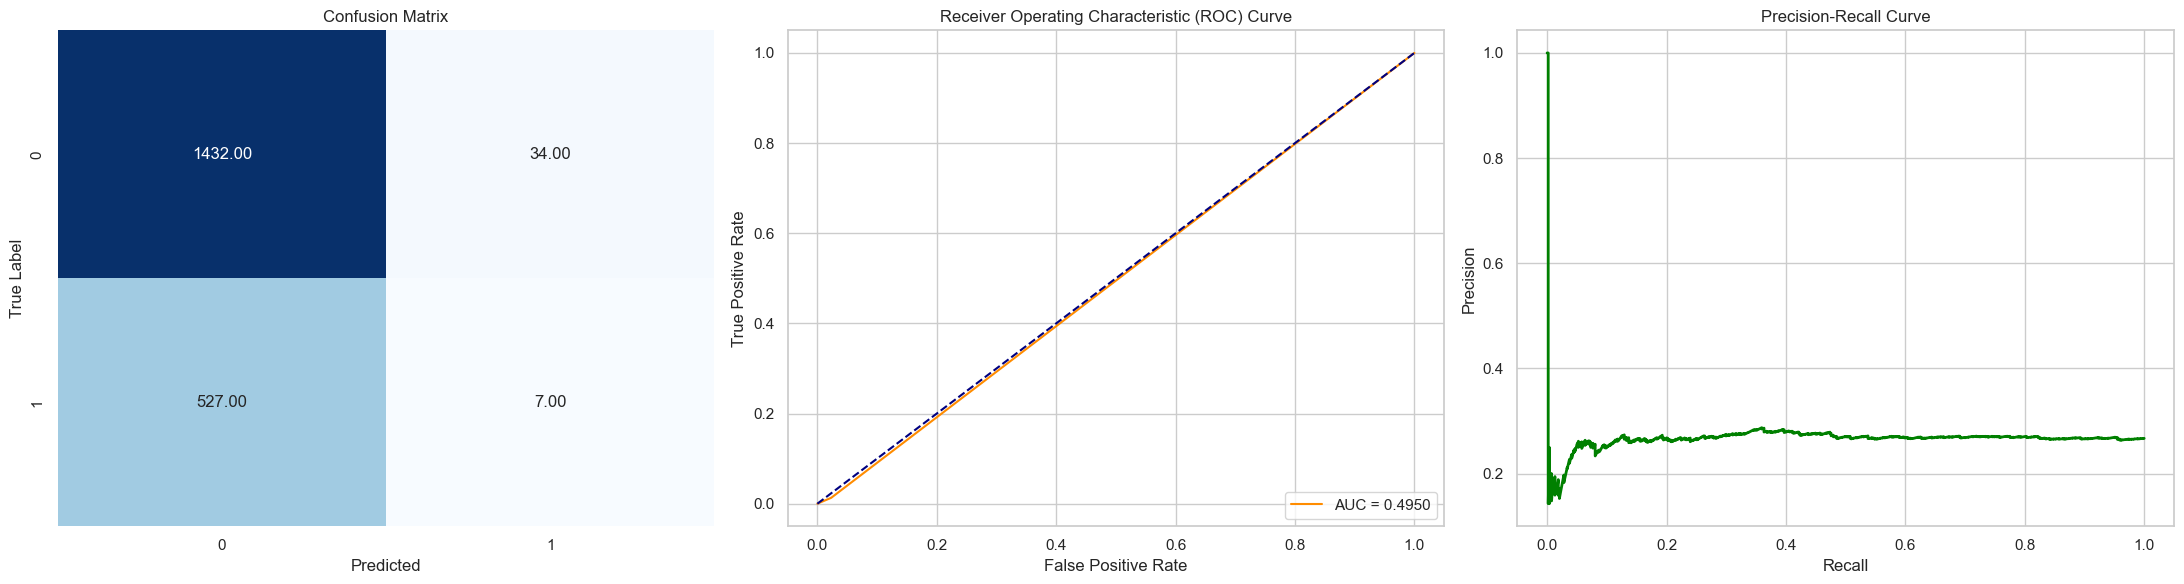

In [33]:
def evaluate_classification_model(model, X_test, y_test):
    y_pred = model.predict(X_test)

    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None

    print(f"Classification Report: \n {classification_report(y_test, y_pred)}")

    metrics = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision (Weighted)': precision_score(y_test, y_pred),
        'Recall (Weighted)': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred)
    }

    if y_prob is not None:
        metrics['ROC-AUC'] = roc_auc_score(y_test, y_pred)

    metrics_df = pd.DataFrame(list(metrics.items()), columns = ['Metric', 'Value'])
    print(f"Summary Metrics: \n {metrics_df.to_string(index = False)}")

    fig, axes = plt.subplots(1, 3, figsize = (22, 6))

    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot = True, fmt = ".2f", cmap = "Blues", ax = axes[0], cbar = False)
    axes[0].set_title('Confusion Matrix')
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('True Label')

    if y_prob is not None:

        fpr, tpr, threshold = roc_curve(y_test, y_pred)
        axes[1].plot(fpr, tpr, label = f"AUC = {metrics['ROC-AUC']:.4f}", color = 'darkorange')
        axes[1].plot([0, 1], [0, 1], color = 'navy', linestyle = '--')
        axes[1].set_title('Receiver Operating Characteristic (ROC) Curve')
        axes[1].set_xlabel('False Positive Rate')
        axes[1].set_ylabel('True Positive Rate')
        axes[1].legend(loc = "lower right")

        precision, recall, _ = precision_recall_curve(y_test, y_prob)
        axes[2].plot(recall, precision, color = 'green', lw = 2)
        axes[2].set_title('Precision-Recall Curve')
        axes[2].set_xlabel('Recall')
        axes[2].set_ylabel('Precision')

    else:
        axes[1].test(0.5, 0.5, 'Probabilities not available\nfor ROC curve', ha = 'center', va = 'center')
        axes[2].text(0.5, 0.5, 'Probabilities not available/nfor PR curve', ha = 'center', va = 'center')

    plt.tight_layout()
    plt.show()

evaluate_classification_model(best_model, X_test, y_test)

In [35]:
def test_random_dataset_samples(model, X_test, y_test, num_samples=3):
    print(f"--- TESTING {num_samples} RANDOM SAMPLES FROM DATASET ---\n")
    
    sample_indices = np.random.choice(X_test.index, size=num_samples, replace=False)
    
    X_samples = X_test.loc[sample_indices]
    y_true = y_test.loc[sample_indices]
    
    y_pred = model.predict(X_samples)
    y_prob = model.predict_proba(X_samples) if hasattr(model, "predict_proba") else None
    
    for i, (idx, row) in enumerate(X_samples.iterrows()):
        print(f"Sample {i+1} (Original Index: {idx})")
        print(f"Features:\n{row.to_dict()}")
        print(f"True Label:      {y_true.loc[idx]}")
        print(f"Predicted Label: {y_pred[i]}")
        
        if y_prob is not None:
            classes = model.classes_
            prob_dict = {str(classes[j]): round(y_prob[i][j], 4) for j in range(len(classes))}
            print(f"Probabilities:   {prob_dict}")
        print("-" * 50)

test_random_dataset_samples(best_model, X_test, y_test, num_samples=3)

--- TESTING 3 RANDOM SAMPLES FROM DATASET ---

Sample 1 (Original Index: 1121)
Features:
{'Unnamed: 0': 1121, 'CustomerID': 1121, 'Gender': 'Male', 'SeniorCitizen': 0, 'Tenure': 23, 'MonthlyCharges': 56.94, 'Contract': 'Two year', 'PaymentMethod': 'Mailed check', 'TotalCharges': 1309.62}
True Label:      0
Predicted Label: 0
Probabilities:   {'0': 0.7226, '1': 0.2774}
--------------------------------------------------
Sample 2 (Original Index: 5896)
Features:
{'Unnamed: 0': 5896, 'CustomerID': 5896, 'Gender': 'Female', 'SeniorCitizen': 0, 'Tenure': 50, 'MonthlyCharges': 49.02, 'Contract': 'Month-to-month', 'PaymentMethod': 'Bank transfer', 'TotalCharges': 2451.0}
True Label:      0
Predicted Label: 0
Probabilities:   {'0': 0.7738, '1': 0.2262}
--------------------------------------------------
Sample 3 (Original Index: 1360)
Features:
{'Unnamed: 0': 1360, 'CustomerID': 1360, 'Gender': 'Female', 'SeniorCitizen': 1, 'Tenure': 23, 'MonthlyCharges': 49.07, 'Contract': 'Two year', 'PaymentM